In [2]:
import os, json, ast
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv
from torch.optim import Adam
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score, classification_report
from tqdm import tqdm
import networkx as nx
import matplotlib.pyplot as plt
import torch.nn as nn

TWITTER15 = "/teamspace/studios/this_studio/misinformation-detection/data/twitter15"
TWITTER16 = "/teamspace/studios/this_studio/misinformation-detection/data/twitter16"
OUTPUTS   = "/teamspace/studios/this_studio/misinformation-detection/outputs/twitter"
os.makedirs(OUTPUTS, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

LABEL_MAP = {'false': 0, 'true': 1, 'unverified': 2, 'non-rumor': 3}

Device: cuda


In [3]:
def load_labels(path):
    labels = {}
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            label, tweet_id = line.split(':')
            labels[tweet_id.strip()] = LABEL_MAP[label.strip()]
    return labels

def load_source_tweets(path):
    tweets = {}
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split('\t', 1)
            if len(parts) == 2:
                tweets[parts[0].strip()] = parts[1].strip()
    return tweets

# load twitter15
t15_labels  = load_labels(f'{TWITTER15}/label.txt')
t15_tweets  = load_source_tweets(f'{TWITTER15}/source_tweets.txt')

# load twitter16
t16_labels  = load_labels(f'{TWITTER16}/label.txt')
t16_tweets  = load_source_tweets(f'{TWITTER16}/source_tweets.txt')

print(f"Twitter15: {len(t15_labels)} labels, {len(t15_tweets)} source tweets")
print(f"Twitter16: {len(t16_labels)} labels, {len(t16_tweets)} source tweets")

# check overlap
print(f"\nT15 label sample: {list(t15_labels.items())[:3]}")
print(f"T15 tweet sample: {list(t15_tweets.items())[:2]}")

Twitter15: 1490 labels, 1490 source tweets
Twitter16: 818 labels, 818 source tweets

T15 label sample: [('731166399389962242', 2), ('714598641827246081', 2), ('691809004356501505', 3)]
T15 tweet sample: [('731166399389962242', '🔥ca kkk grand wizard 🔥 endorses @hillaryclinton #neverhillary #trump2016 URL'), ('714598641827246081', 'an open letter to trump voters from his top strategist-turned-defector URL via @xojanedotcom')]


In [4]:
from transformers import BertTokenizer, BertModel

tokenizer    = BertTokenizer.from_pretrained('bert-base-uncased')
bert_encoder = BertModel.from_pretrained('bert-base-uncased').to(device)
bert_encoder.eval()

def get_embeddings_dict(id_text_dict, tokenizer, model, batch_size=64):
    """Returns {tweet_id: embedding_vector}"""
    ids    = list(id_text_dict.keys())
    texts  = [id_text_dict[i] for i in ids]
    embeddings = {}

    for i in tqdm(range(0, len(texts), batch_size), desc="embedding"):
        batch_ids   = ids[i:i+batch_size]
        batch_texts = texts[i:i+batch_size]
        encoding = tokenizer(
            batch_texts,
            max_length     = 128,
            padding        = 'max_length',
            truncation     = True,
            return_tensors = 'pt'
        )
        input_ids      = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)

        with torch.no_grad():
            outputs = bert_encoder(input_ids=input_ids,
                                   attention_mask=attention_mask)
            vecs    = outputs.last_hidden_state[:, 0, :].cpu().numpy()

        for tid, vec in zip(batch_ids, vecs):
            embeddings[tid] = vec

    return embeddings

print("Embedding Twitter15 source tweets...")
t15_embeddings = get_embeddings_dict(t15_tweets, tokenizer, bert_encoder)

print("Embedding Twitter16 source tweets...")
t16_embeddings = get_embeddings_dict(t16_tweets, tokenizer, bert_encoder)

print(f"T15 embeddings: {len(t15_embeddings)}")
print(f"T16 embeddings: {len(t16_embeddings)}")

# save
np.save(f'{OUTPUTS}/t15_source_embeddings.npy',
        np.stack(list(t15_embeddings.values())))
np.save(f'{OUTPUTS}/t16_source_embeddings.npy',
        np.stack(list(t16_embeddings.values())))
with open(f'{OUTPUTS}/t15_embedding_ids.json', 'w') as f:
    json.dump(list(t15_embeddings.keys()), f)
with open(f'{OUTPUTS}/t16_embedding_ids.json', 'w') as f:
    json.dump(list(t16_embeddings.keys()), f)
print("Saved embeddings.")

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Embedding Twitter15 source tweets...


embedding: 100%|██████████| 24/24 [00:09<00:00,  2.41it/s]


Embedding Twitter16 source tweets...


embedding: 100%|██████████| 13/13 [00:05<00:00,  2.46it/s]

T15 embeddings: 1490
T16 embeddings: 818
Saved embeddings.


Running t-SNE for Twitter15...
Running UMAP for Twitter15...


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


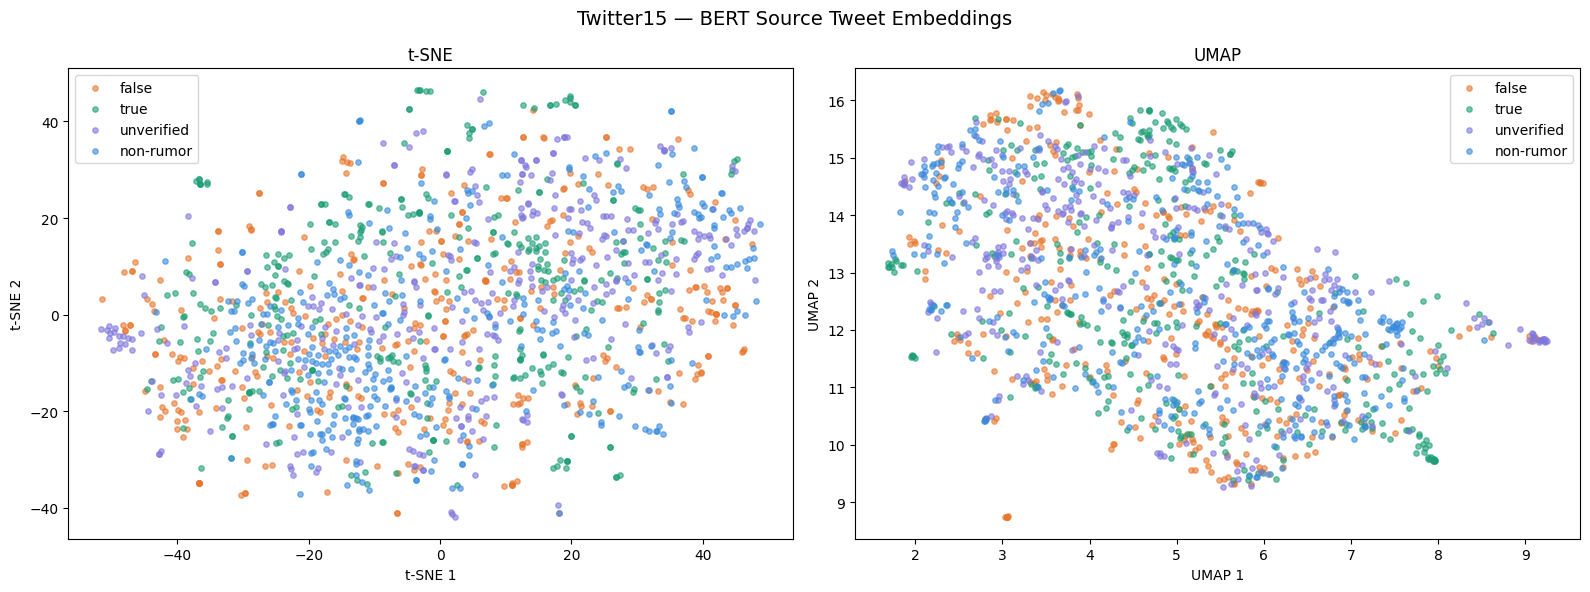

Saved Twitter15_embeddings_viz.png
Running t-SNE for Twitter16...
Running UMAP for Twitter16...


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


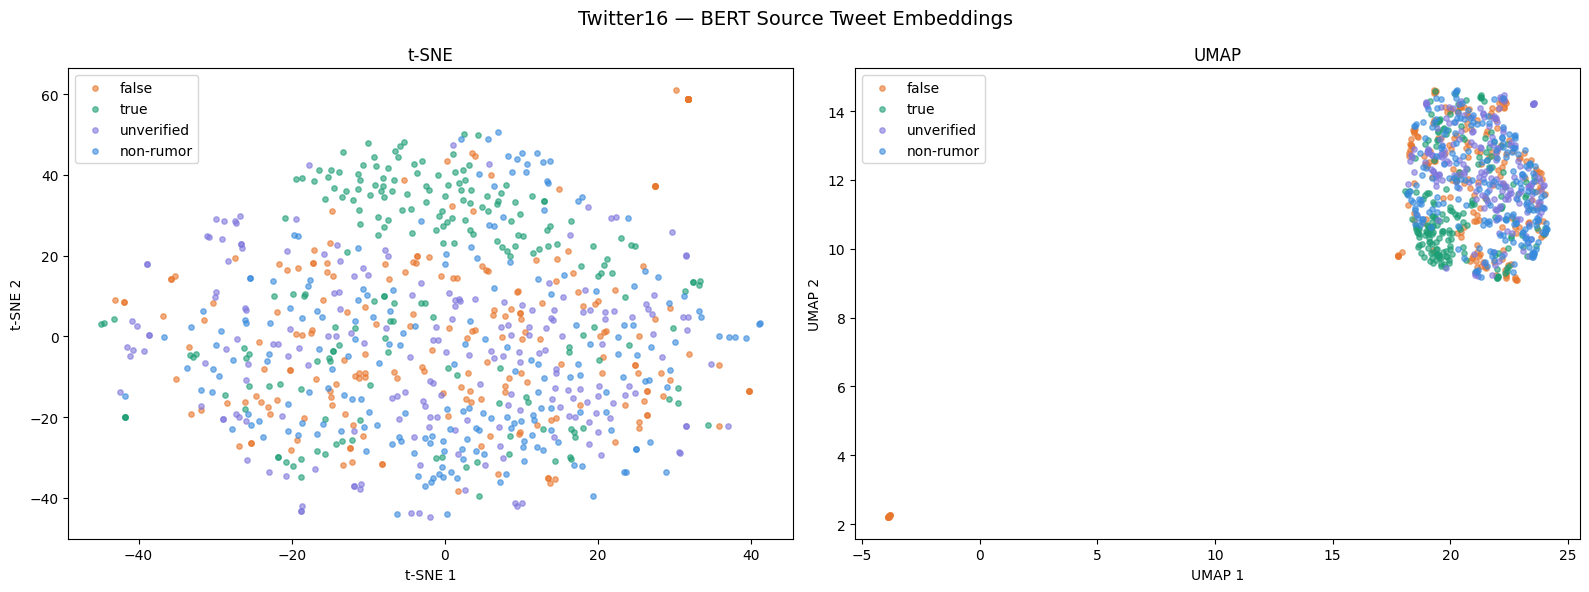

Saved Twitter16_embeddings_viz.png


In [5]:
from sklearn.manifold import TSNE
import umap

def plot_embeddings(embeddings_dict, labels_dict, dataset_name):
    # align
    ids    = [tid for tid in embeddings_dict if tid in labels_dict]
    X      = np.stack([embeddings_dict[tid] for tid in ids])
    y      = np.array([labels_dict[tid] for tid in ids])
    
    label_names = {0: 'false', 1: 'true', 2: 'unverified', 3: 'non-rumor'}
    colors      = {0: '#E8772E', 1: '#1D9E75', 2: '#7F77DD', 3: '#378ADD'}

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'{dataset_name} — BERT Source Tweet Embeddings', fontsize=14)

    # t-SNE
    print(f"Running t-SNE for {dataset_name}...")
    tsne   = TSNE(n_components=2, random_state=42, perplexity=30)
    X_tsne = tsne.fit_transform(X)

    for label_id, label_name in label_names.items():
        mask = y == label_id
        axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                        c=colors[label_id], label=label_name,
                        alpha=0.6, s=15)
    axes[0].set_title('t-SNE')
    axes[0].legend()
    axes[0].set_xlabel('t-SNE 1')
    axes[0].set_ylabel('t-SNE 2')

    # UMAP
    print(f"Running UMAP for {dataset_name}...")
    reducer = umap.UMAP(n_components=2, random_state=42)
    X_umap  = reducer.fit_transform(X)

    for label_id, label_name in label_names.items():
        mask = y == label_id
        axes[1].scatter(X_umap[mask, 0], X_umap[mask, 1],
                        c=colors[label_id], label=label_name,
                        alpha=0.6, s=15)
    axes[1].set_title('UMAP')
    axes[1].legend()
    axes[1].set_xlabel('UMAP 1')
    axes[1].set_ylabel('UMAP 2')

    plt.tight_layout()
    plt.savefig(f'{OUTPUTS}/{dataset_name}_embeddings_viz.png', dpi=150)
    plt.show()
    print(f"Saved {dataset_name}_embeddings_viz.png")

plot_embeddings(t15_embeddings, t15_labels, 'Twitter15')
plot_embeddings(t16_embeddings, t16_labels, 'Twitter16')

In [6]:
def parse_tree(tree_path, root_id, embedding, label, cut_minutes=None):
    """
    Parse a Twitter15/16 tree file into a PyG Data object.
    All nodes share the source tweet BERT embedding.
    Node features: BERT(768) + depth(1) + degree(1) + t_min_norm(1) = 771
    """
    edges    = []   # (parent_user, child_user, time)
    nodes    = {}   # user_id -> time_offset

    with open(tree_path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            # parse: ['uid1','tid1','t1']->['uid2','tid2','t2']
            parts = line.split('->')
            if len(parts) != 2:
                continue
            try:
                parent = ast.literal_eval(parts[0].strip())
                child  = ast.literal_eval(parts[1].strip())
            except:
                continue

            p_uid, p_tid, p_time = parent
            c_uid, c_tid, c_time = child

            # skip ROOT self-loop
            if p_uid == 'ROOT':
                # root node
                nodes[root_id] = 0.0
                nodes[c_uid]   = float(c_time)
                edges.append((root_id, c_uid, float(c_time)))
            else:
                nodes[p_uid] = float(p_time)
                nodes[c_uid] = float(c_time)
                edges.append((p_uid, c_uid, float(c_time)))

    # apply time cut — remove edges/nodes after cut
    if cut_minutes is not None:
        edges = [(p, c, t) for p, c, t in edges if t <= cut_minutes]
        # keep only nodes that appear in remaining edges
        valid_nodes = set()
        for p, c, t in edges:
            valid_nodes.add(p)
            valid_nodes.add(c)
        valid_nodes.add(root_id)
        nodes = {n: t for n, t in nodes.items() if n in valid_nodes}

    if len(nodes) < 2 or len(edges) == 0:
        return None

    # node index mapping
    node_list   = list(nodes.keys())
    node_to_idx = {n: i for i, n in enumerate(node_list)}
    n_nodes     = len(node_list)

    # timestamps
    t_vals  = np.array([nodes[n] for n in node_list], dtype=np.float32)
    t_max   = t_vals.max() if t_vals.max() > 0 else 1.0
    t_norms = t_vals / t_max

    # depth — BFS from root
    import networkx as nx
    G_nx = nx.DiGraph()
    for p, c, t in edges:
        if p in node_to_idx and c in node_to_idx:
            G_nx.add_edge(p, c)
    try:
        depths = nx.single_source_shortest_path_length(G_nx, root_id)
    except:
        depths = {n: 0 for n in node_list}
    depth_vals  = np.array([depths.get(n, 0) for n in node_list],
                            dtype=np.float32)
    depth_max   = depth_vals.max() if depth_vals.max() > 0 else 1.0
    depth_norms = depth_vals / depth_max

    # degree
    degrees  = np.array([G_nx.degree(n) if n in G_nx else 0
                          for n in node_list], dtype=np.float32)
    deg_max  = degrees.max() if degrees.max() > 0 else 1.0
    deg_norm = degrees / deg_max

    # build feature matrix — all nodes get source tweet embedding
    bert_vec  = embedding.astype(np.float32)
    feat_list = []
    for i in range(n_nodes):
        extra = np.array([depth_norms[i], deg_norm[i], t_norms[i]],
                          dtype=np.float32)
        feat_list.append(np.concatenate([bert_vec, extra]))

    x = torch.tensor(np.stack(feat_list), dtype=torch.float)

    # TD edges
    td_edges = [(node_to_idx[p], node_to_idx[c])
                for p, c, t in edges
                if p in node_to_idx and c in node_to_idx]
    if len(td_edges) == 0:
        return None

    td_src, td_dst = zip(*td_edges)
    td_edge_index  = torch.tensor([td_src, td_dst], dtype=torch.long)
    bu_edge_index  = torch.tensor([td_dst, td_src], dtype=torch.long)

    root_idx = node_to_idx.get(root_id, 0)

    return Data(
        x             = x,
        edge_index    = td_edge_index,
        BU_edge_index = bu_edge_index,
        y             = torch.tensor([label], dtype=torch.long),
        root_index    = torch.tensor([root_idx], dtype=torch.long),
        num_nodes     = n_nodes
    )

In [7]:
def build_dataset(tree_dir, labels_dict, embeddings_dict, cut_minutes=None, dataset_name=''):
    data_list = []
    skipped   = 0

    tree_files = [f for f in os.listdir(tree_dir) if f.endswith('.txt')]

    for fname in tqdm(tree_files, desc=f"{dataset_name} cut={cut_minutes}"):
        root_id = fname.replace('.txt', '')

        if root_id not in labels_dict:
            skipped += 1
            data_list.append(None)
            continue
        if root_id not in embeddings_dict:
            skipped += 1
            data_list.append(None)
            continue

        label     = labels_dict[root_id]
        embedding = embeddings_dict[root_id]
        tree_path = os.path.join(tree_dir, fname)

        d = parse_tree(tree_path, root_id, embedding, label,
                       cut_minutes=cut_minutes)
        if d is None:
            skipped += 1
            data_list.append(None)
        else:
            data_list.append(d)

    print(f"  {dataset_name} cut={cut_minutes}: "
          f"{len(data_list)-skipped} valid, {skipped} skipped")
    return data_list

cuts       = [60, 120, 240, None]
cut_labels = ['60min', '120min', '240min', 'full']

t15_datasets = {}
t16_datasets = {}

for cut, cut_label in zip(cuts, cut_labels):
    t15_datasets[cut_label] = build_dataset(
        f'{TWITTER15}/tree', t15_labels, t15_embeddings,
        cut_minutes=cut, dataset_name='T15'
    )
    t16_datasets[cut_label] = build_dataset(
        f'{TWITTER16}/tree', t16_labels, t16_embeddings,
        cut_minutes=cut, dataset_name='T16'
    )

T15 cut=60: 100%|██████████| 1490/1490 [00:24<00:00, 60.54it/s]


  T15 cut=60: 1490 valid, 0 skipped


T16 cut=60: 100%|██████████| 818/818 [00:14<00:00, 58.00it/s]


  T16 cut=60: 818 valid, 0 skipped


T15 cut=120: 100%|██████████| 1490/1490 [00:25<00:00, 59.51it/s]


...

  T16 cut=240: 818 valid, 0 skipped


T15 cut=None: 100%|██████████| 1490/1490 [00:34<00:00, 43.27it/s]


  T15 cut=None: 1490 valid, 0 skipped


T16 cut=None: 100%|██████████| 818/818 [00:20<00:00, 40.02it/s]

  T16 cut=None: 818 valid, 0 skipped


In [8]:
import copy
from torch_scatter import scatter_mean

class TDrumorGCN(nn.Module):
    def __init__(self, in_feats, hid_feats, out_feats):
        super().__init__()
        self.conv1 = GCNConv(in_feats, hid_feats)
        self.conv2 = GCNConv(hid_feats + in_feats, out_feats)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x1         = copy.copy(x.float())           # original features
        x          = self.conv1(x, edge_index)
        x2         = copy.copy(x)                   # after conv1

        # tile root features to all nodes
        root_index  = data.root_index
        batch_size  = int(data.batch.max()) + 1
        root_extend = torch.zeros(len(data.batch), x1.size(1)).to(x.device)
        for b in range(batch_size):
            mask = (data.batch == b)
            root_extend[mask] = x1[root_index[b]]

        x = torch.cat((x, root_extend), dim=1)     # (n, hid+in)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.relu(x)

        # tile conv1 root features again
        root_extend2 = torch.zeros(len(data.batch), x2.size(1)).to(x.device)
        for b in range(batch_size):
            mask = (data.batch == b)
            root_extend2[mask] = x2[root_index[b]]

        x = torch.cat((x, root_extend2), dim=1)    # (n, out+hid)
        x = scatter_mean(x, data.batch, dim=0)     # (batch_size, out+hid)
        return x

class BUrumorGCN(nn.Module):
    def __init__(self, in_feats, hid_feats, out_feats):
        super().__init__()
        self.conv1 = GCNConv(in_feats, hid_feats)
        self.conv2 = GCNConv(hid_feats + in_feats, out_feats)

    def forward(self, data):
        x, edge_index = data.x, data.BU_edge_index
        x1         = copy.copy(x.float())
        x          = self.conv1(x, edge_index)
        x2         = copy.copy(x)

        root_index  = data.root_index
        batch_size  = int(data.batch.max()) + 1
        root_extend = torch.zeros(len(data.batch), x1.size(1)).to(x.device)
        for b in range(batch_size):
            mask = (data.batch == b)
            root_extend[mask] = x1[root_index[b]]

        x = torch.cat((x, root_extend), dim=1)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.relu(x)

        root_extend2 = torch.zeros(len(data.batch), x2.size(1)).to(x.device)
        for b in range(batch_size):
            mask = (data.batch == b)
            root_extend2[mask] = x2[root_index[b]]

        x = torch.cat((x, root_extend2), dim=1)
        x = scatter_mean(x, data.batch, dim=0)
        return x

class BiGCN(nn.Module):
    def __init__(self, in_feats, hid_feats, out_feats, num_classes=4):
        super().__init__()
        self.td_gcn = TDrumorGCN(in_feats, hid_feats, out_feats)
        self.bu_gcn = BUrumorGCN(in_feats, hid_feats, out_feats)
        # output of each GCN is (out_feats + hid_feats)
        self.fc     = nn.Linear((out_feats + hid_feats) * 2, num_classes)

    def forward(self, data):
        td_x = self.td_gcn(data)                    # (B, out+hid)
        bu_x = self.bu_gcn(data)                    # (B, out+hid)
        x    = torch.cat((td_x, bu_x), dim=1)       # (B, (out+hid)*2)
        x    = self.fc(x)
        x    = F.log_softmax(x, dim=1)
        return x

In [9]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out  = model(data)
        loss = criterion(out, data.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds  = []
    all_labels = []
    for data in loader:
        data  = data.to(device)
        out   = model(data)
        preds = out.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(data.y.cpu().numpy())
    return np.array(all_preds), np.array(all_labels)

def run_cv(data_list, dataset_name, n_splits=5,
           hid_feats=64, out_feats=64,
           epochs=200, lr=0.0005, batch_size=32):

    valid_idx    = [i for i, d in enumerate(data_list) if d is not None]
    valid_data   = [data_list[i] for i in valid_idx]
    valid_labels = np.array([d.y.item() for d in valid_data])

    cv        = StratifiedKFold(n_splits=n_splits, shuffle=True,
                                random_state=42)
    all_preds = np.zeros(len(valid_labels), dtype=int)

    for fold, (train_idx, val_idx) in enumerate(
            cv.split(valid_data, valid_labels)):
        print(f"  Fold {fold+1}/{n_splits}", end=' ')

        train_data   = [valid_data[i] for i in train_idx]
        val_data     = [valid_data[i] for i in val_idx]
        train_loader = DataLoader(train_data, batch_size=batch_size,
                                  shuffle=True)
        val_loader   = DataLoader(val_data,   batch_size=batch_size,
                                  shuffle=False)

        model     = BiGCN(in_feats=771, hid_feats=hid_feats,
                          out_feats=out_feats, num_classes=4).to(device)

        # separate LR for BU — faithful to original
        BU_params  = list(map(id, model.bu_gcn.conv1.parameters()))
        BU_params += list(map(id, model.bu_gcn.conv2.parameters()))
        base_params = filter(lambda p: id(p) not in BU_params,
                             model.parameters())
        optimizer = Adam([
            {'params': base_params},
            {'params': model.bu_gcn.conv1.parameters(), 'lr': lr/5},
            {'params': model.bu_gcn.conv2.parameters(), 'lr': lr/5},
        ], lr=lr, weight_decay=1e-4)

        criterion = torch.nn.NLLLoss()

        # early stopping variables
        best_f1       = 0
        patience      = 10
        patience_ctr  = 0
        best_preds    = None

        for epoch in range(epochs):
            loss = train_epoch(model, train_loader, optimizer, criterion)

            # evaluate every epoch for early stopping
            preds, labels = evaluate(model, val_loader)
            val_f1 = f1_score(labels, preds, average='macro')

            if val_f1 > best_f1:
                best_f1    = val_f1
                best_preds = preds.copy()
                patience_ctr = 0
            else:
                patience_ctr += 1

            if (epoch + 1) % 10 == 0:
                print(f"\n    Epoch {epoch+1} | Loss: {loss:.4f} "
                      f"| Val F1: {val_f1:.4f}", end=' ')

            if patience_ctr >= patience:
                print(f"\n    Early stop at epoch {epoch+1}")
                break

        all_preds[val_idx] = best_preds if best_preds is not None else preds

        fold_f1  = f1_score(valid_labels[val_idx],
                            all_preds[val_idx], average='macro')
        fold_acc = accuracy_score(valid_labels[val_idx],
                                  all_preds[val_idx])
        print(f"| Best Macro-F1: {fold_f1:.4f} | Acc: {fold_acc:.4f}")

    macro_f1 = f1_score(valid_labels, all_preds, average='macro')
    accuracy = accuracy_score(valid_labels, all_preds)
    print(f"\n  [{dataset_name}] Macro-F1: {macro_f1:.4f} | "
          f"Accuracy: {accuracy:.4f}")
    print(classification_report(valid_labels, all_preds,
                                 target_names=['false','true',
                                               'unverified','non-rumor']))
    return all_preds, valid_labels, macro_f1, accuracy

In [10]:
# sanity check
sample_data   = [d for d in t15_datasets['full'][:50] if d is not None]
sample_loader = DataLoader(sample_data, batch_size=8)
model_test    = BiGCN(in_feats=771, hid_feats=128, out_feats=128,
                      num_classes=4).to(device)
batch         = next(iter(sample_loader))
batch         = batch.to(device)
out           = model_test(batch)
print(f"Output shape: {out.shape}")  # should be (8, 4)
print("Forward pass OK")

Output shape: torch.Size([8, 4])
Forward pass OK


In [11]:
results = {'T15': {}, 'T16': {}}
for cut_label in cut_labels:
    print(f"\n{'='*60}")
    print(f"TWITTER15 | Time cut: {cut_label}")
    print(f"{'='*60}")
    preds, labels, f1, acc = run_cv(
        t15_datasets[cut_label],
        dataset_name='T15',
        epochs=200,
        batch_size=32
    )
    results['T15'][cut_label] = {'macro_f1': f1, 'accuracy': acc}

    print(f"\n{'='*60}")
    print(f"TWITTER16 | Time cut: {cut_label}")
    print(f"{'='*60}")
    preds, labels, f1, acc = run_cv(
        t16_datasets[cut_label],
        dataset_name='T16',
        epochs=200,
        batch_size=32
    )
    results['T16'][cut_label] = {'macro_f1': f1, 'accuracy': acc}


TWITTER15 | Time cut: 60min
  Fold 1/5 
    Epoch 10 | Loss: 0.7304 | Val F1: 0.5729 
    Epoch 20 | Loss: 0.3693 | Val F1: 0.6368 
    Epoch 30 | Loss: 0.1637 | Val F1: 0.6484 
    Early stop at epoch 39
| Best Macro-F1: 0.6656 | Acc: 0.6644
  Fold 2/5 
    Epoch 10 | Loss: 0.7105 | Val F1: 0.5617 
    Epoch 20 | Loss: 0.3657 | Val F1: 0.6001 
    Epoch 30 | Loss: 0.1646 | Val F1: 0.6135 
    Early stop at epoch 32
| Best Macro-F1: 0.6217 | Acc: 0.6242
  Fold 3/5 
    Epoch 10 | Loss: 0.7445 | Val F1: 0.5734 
    Epoch 20 | Loss: 0.3770 | Val F1: 0.6571 
    Early stop at epoch 26
| Best Macro-F1: 0.6619 | Acc: 0.6611
  Fold 4/5 
    Epoch 10 | Loss: 0.7002 | Val F1: 0.5767 
    Epoch 20 | Loss: 0.3844 | Val F1: 0.6303 
    Early stop at epoch 23
| Best Macro-F1: 0.6737 | Acc: 0.6745
  Fold 5/5 
    Epoch 10 | Loss: 0.7246 | Val F1: 0.5892 
    Epoch 20 | Loss: 0.3785 | Val F1: 0.6424 
    Early stop at epoch 24
| Best Macro-F1: 0.6530 | Acc: 0.6544

  [T15] Macro-F1: 0.6554 | Accura

  dataset     cut  macro_f1  accuracy
0     T15   60min  0.655371  0.655705
1     T15  120min  0.656167  0.657047
2     T15  240min  0.654160  0.654362
3     T15    full  0.654189  0.654362
4     T16   60min  0.720384  0.721271
5     T16  120min  0.705856  0.707824
6     T16  240min  0.731729  0.732274
7     T16    full  0.714976  0.715159


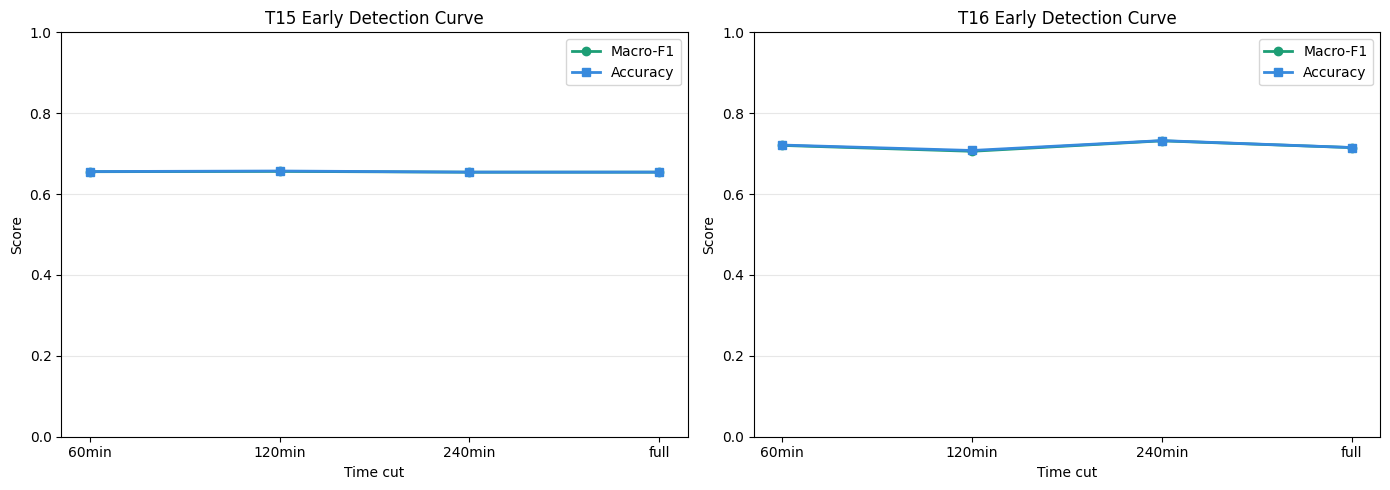

Saved twitter_early_detection_curves.png


In [12]:
# save results
results_rows = []
for dataset in ['T15', 'T16']:
    for cut_label in cut_labels:
        results_rows.append({
            'dataset'  : dataset,
            'cut'      : cut_label,
            'macro_f1' : results[dataset][cut_label]['macro_f1'],
            'accuracy' : results[dataset][cut_label]['accuracy']
        })

results_df = pd.DataFrame(results_rows)
results_df.to_csv(f'{OUTPUTS}/twitter_results.csv', index=False)
print(results_df.to_string())

# plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dataset in zip(axes, ['T15', 'T16']):
    f1s  = [results[dataset][c]['macro_f1'] for c in cut_labels]
    accs = [results[dataset][c]['accuracy'] for c in cut_labels]

    ax.plot(cut_labels, f1s,  marker='o', linewidth=2,
            color='#1D9E75', label='Macro-F1')
    ax.plot(cut_labels, accs, marker='s', linewidth=2,
            color='#378ADD', label='Accuracy')
    ax.set_title(f'{dataset} Early Detection Curve')
    ax.set_xlabel('Time cut')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUTS}/twitter_early_detection_curves.png', dpi=150)
plt.show()
print("Saved twitter_early_detection_curves.png")